# Chapter 3 -- The SVM Optimization Problem

This chapter derives the central mathematical object of Support Vector Machines: the **convex quadratic optimization problem** whose solution is the optimal separating hyperplane. We build it up step by step, starting from a naive attempt to compare two hyperplanes and ending with the canonical formulation found in every SVM paper:

$$\begin{aligned}
\min_{\mathbf{w},\,b} \quad & \tfrac{1}{2}\|\mathbf{w}\|^2 \\
\text{subject to} \quad & y_i(\mathbf{w}\cdot\mathbf{x}_i + b) - 1 \geq 0, \quad i = 1,\dots,m
\end{aligned}$$

Along the way we cover four big ideas:

1. **The functional margin** $f = y(\mathbf{w}\cdot\mathbf{x}+b)$ -- a first attempt to score a hyperplane that handles classification correctness but fails under rescaling.
2. **The geometric margin** $\gamma = y\!\left(\frac{\mathbf{w}}{\|\mathbf{w}\|}\cdot\mathbf{x} + \frac{b}{\|\mathbf{w}\|}\right)$ -- a scale-invariant fix that has a clean geometric meaning (the perpendicular distance from a point to the hyperplane).
3. **Constrained optimization basics** -- unconstrained vs. constrained problems, equality and inequality constraints, the feasible set, and quadratic programs.
4. **The SVM derivation** -- how maximizing the geometric margin transforms into minimizing $\tfrac{1}{2}\|\mathbf{w}\|^2$ via the rescaling trick $F = 1$.

The connection to earlier material: Chapter 2 introduced the Perceptron, which finds *some* separating hyperplane but not a unique one. The SVM commits to *the* hyperplane -- the one whose decision boundary sits as far as possible from every training point. This chapter answers the question *"how do we even define such a thing mathematically?"* The next chapter will solve the optimization problem we derive here.

## Setup

We need only `numpy` for the linear algebra and `matplotlib` for the visualizations. The chapter is intentionally library-light: the goal is to expose the mathematics, not hide it behind `sklearn.svm.SVC`.

In [1]:
# Install required packages (Colab-friendly)
!pip install -q numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducibility and consistent figure aesthetics
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"NumPy version: {np.__version__}")
print("Setup complete.")

NumPy version: 2.0.2
Setup complete.


The setup is minimal because Chapter 3 is mathematical scaffolding: we are *building* the SVM objective, not yet calling a library that solves it. Every formula we derive will become a few lines of NumPy so that the algebra is concrete. Later chapters can then plug the same objective into a QP solver such as `cvxopt`.

## 1. SVMs search for *the* optimal hyperplane

The Perceptron from the previous chapter has a known weakness: **it finds a separating hyperplane, but not the same one every time**. The hyperplane it returns depends on the order in which training examples are visited and on the initial weights. If by chance it stops on a hyperplane that hugs one of the classes, it will generalize poorly to unseen data drawn from the same distribution.

SVMs commit to a stronger objective. Among the *infinite* set of hyperplanes that separate a linearly separable dataset, the SVM picks the unique one we will call **the optimal hyperplane** -- the one that *best* separates the data. Before we can find it, we need a number that quantifies how good a given hyperplane is. The next sections build that number from scratch.

## 2. How can we compare two hyperplanes?

### 2.1 Using the equation of the hyperplane

A hyperplane in $\mathbb{R}^p$ is the set of points $\mathbf{x}$ satisfying

$$\mathbf{w}\cdot\mathbf{x} + b = 0,$$

where $\mathbf{w} \in \mathbb{R}^p$ is a normal vector and $b \in \mathbb{R}$ is the bias. A point on the hyperplane returns $0$. A point off the hyperplane returns a non-zero value, and **the magnitude grows with the distance** from the hyperplane while **the sign tells us which side of the hyperplane the point is on**.

Consider the line in Figure 22 of the chapter, defined by $\mathbf{w} = (-0.4,\,-1)$ and $b = 9$. We evaluate $\mathbf{w}\cdot\mathbf{x} + b$ at three points $A(1,3)$, $B(3,5)$, $C(5,7)$.

In [2]:
# Hyperplane parameters (Figure 22 from the chapter)
w = np.array([-0.4, -1])
b = 9

# Three test points
A = np.array([1, 3])
B = np.array([3, 5])
C = np.array([5, 7])

for name, pt in [('A', A), ('B', B), ('C', C)]:
    val = float(np.dot(w, pt) + b)
    print(f"Point {name}({pt[0]},{pt[1]}): w . {name.lower()} + b = {val}")

Point A(1,3): w . a + b = 5.6
Point B(3,5): w . b + b = 2.8
Point C(5,7): w . c + b = 0.0


We obtain exactly the values reported in the chapter: $5.6$ for $A$, $2.8$ for $B$, and $0$ for $C$. The point $C(5,7)$ sits *on* the hyperplane (since $-0.4\cdot 5 + (-1)\cdot 7 + 9 = -2 - 7 + 9 = 0$), while $A$ and $B$ are off it. The fact that $A$ produces a *larger* number ($5.6$) than $B$ ($2.8$) confirms a useful intuition:

$$\beta = \mathbf{w}\cdot\mathbf{x} + b \quad\text{is, up to a scale factor, a proxy for distance.}$$

A first idea for comparing two hyperplanes: for each hyperplane, compute $\beta$ for every training point, take the *minimum* (the closest point), and prefer the hyperplane whose minimum is the largest -- the one that pushes the closest point as far away as possible.

Formally, for a dataset $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{m}$ define

$$B = \min_{i=1\dots m} \beta_i = \min_{i=1\dots m} (\mathbf{w}\cdot\mathbf{x}_i + b),$$

and pick the hyperplane that maximizes $B$. This is the seed of the margin idea, but as we will see it has two defects we need to fix.

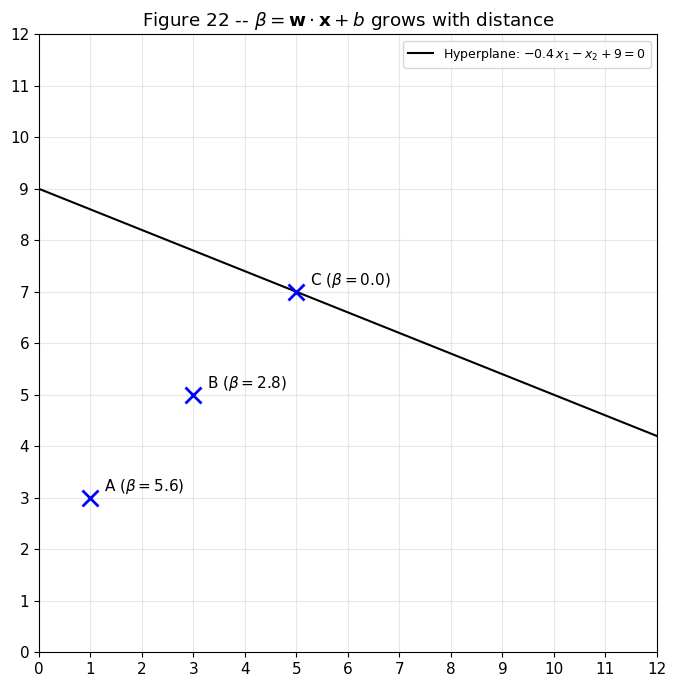

In [3]:
# Visualize Figure 22: the hyperplane and the three points
fig, ax = plt.subplots(figsize=(7, 7))

# Plot the hyperplane: -0.4*x1 - x2 + 9 = 0  =>  x2 = -0.4*x1 + 9
x_line = np.linspace(0, 12, 100)
y_line = -0.4 * x_line + 9
ax.plot(x_line, y_line, 'k-', linewidth=1.5,
        label=r'Hyperplane: $-0.4\,x_1 - x_2 + 9 = 0$')

# Plot the three points
points = {'A': (1, 3), 'B': (3, 5), 'C': (5, 7)}
values = {'A': 5.6, 'B': 2.8, 'C': 0.0}
for name, (px, py) in points.items():
    ax.plot(px, py, 'x', color='blue', markersize=12, mew=2)
    ax.annotate(f'{name} ($\\beta={values[name]}$)', (px, py),
                textcoords="offset points", xytext=(10, 5), fontsize=11)

ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.set_xticks(range(13)); ax.set_yticks(range(13))
ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=9)
ax.set_title(r'Figure 22 -- $\beta = \mathbf{w}\cdot\mathbf{x} + b$ grows with distance')
plt.tight_layout(); plt.show()

The figure makes the magnitude-distance relationship visible: $A$ is far below the line and yields the largest $\beta = 5.6$, $B$ is closer and yields $\beta = 2.8$, and $C$ sits on the line with $\beta = 0$. **The sign of $\beta$ also encodes the side of the hyperplane** -- this becomes important the moment we introduce labels $y_i \in \{-1, +1\}$.

### 2.2 Problem: examples on the negative side

The "minimum $\beta$" recipe sounds reasonable, but it breaks for points on the negative side of the hyperplane. Consider two points with $\beta = -5$ and $\beta = -1$. The point with $\beta = -1$ is **closer** to the hyperplane than the one with $\beta = -5$ (because $|-1| < |-5|$), yet a naive `min` would pick $-5$ as smaller. The natural fix is to take **absolute values**:

$$B = \min_{i=1\dots m} |\beta_i|.$$

This works as a distance proxy, but it throws away another piece of information we want to keep: *whether the example is correctly classified*. Two hyperplanes with the same $|B|$ can be very different -- one might classify everything correctly, the other might classify everything wrong (Figures 25-26 in the chapter). We need a single number that is both **a distance** and **a correctness indicator**.

### 2.3 Does the hyperplane correctly classify the data? -- the functional margin

The element we have not used yet is the **label** $y \in \{-1, +1\}$. Multiplying $\beta$ by $y$ defines a new quantity:

$$f = y \cdot \beta = y \, (\mathbf{w}\cdot\mathbf{x} + b).$$

This number has the property we want:

$$\operatorname{sign}(f) = \begin{cases} +1 & \text{if the point is correctly classified}\\ -1 & \text{otherwise} \end{cases}$$

Why? If a positive example ($y=+1$) sits on the positive side ($\beta > 0$), then $f = (+1)\cdot(+\beta) > 0$. If a negative example ($y=-1$) sits on the negative side ($\beta < 0$), then $f = (-1)\cdot(-\beta) > 0$. A misclassification flips exactly one of the two signs and produces $f < 0$.

For a whole dataset the **functional margin of $\mathcal{D}$** is

$$F = \min_{i=1\dots m} f_i = \min_{i=1\dots m} y_i(\mathbf{w}\cdot\mathbf{x}_i + b).$$

Larger $F$ is better. Code Listing 19 implements this directly.

In [4]:
# Code Listing 19 -- functional margin

def example_functional_margin(w, b, x, y):
    # Functional margin of a single example (x, y) w.r.t. hyperplane (w, b)
    return y * (np.dot(w, x) + b)

def functional_margin(w, b, X, y):
    # Functional margin of a hyperplane on a labeled dataset
    return np.min([example_functional_margin(w, b, x, y[i])
                   for i, x in enumerate(X)])

# Quick sanity check on a single point
x_test = np.array([1, 1])
y_test = 1
w_test = np.array([2, 1])
b_test = 5
f_val = example_functional_margin(w_test, b_test, x_test, y_test)
print(f"f for x=(1,1), y=+1, w=(2,1), b=5: {f_val}")
print(f"  Computed by hand: 1 * (2*1 + 1*1 + 5) = 1 * 8 = 8")

f for x=(1,1), y=+1, w=(2,1), b=5: 8
  Computed by hand: 1 * (2*1 + 1*1 + 5) = 1 * 8 = 8


The result is $f = 8$, matching the hand computation. The function is just the dot product plus bias, multiplied by the label. We will use it as a building block for everything that follows.

### 2.4 Scale invariance -- the critical defect of the functional margin

The functional margin has a fatal flaw that disqualifies it as an optimization objective: **it is not scale invariant**. A hyperplane is determined by the *direction* of $\mathbf{w}$, not by its length. The hyperplanes defined by $(\mathbf{w}, b)$ and $(10\mathbf{w}, 10b)$ are *the same hyperplane*. But the functional margin of the second is *ten times larger* than the first.

This means a malicious optimizer can drive $F \to \infty$ simply by rescaling $\mathbf{w}$ without ever changing the actual hyperplane. The quantity $F$ does not encode anything intrinsic about the geometry. Code Listing 20 demonstrates this concretely.

In [5]:
# Code Listing 20 -- functional margin is not scale invariant

x = np.array([1, 1])
y = 1

b_1 = 5
w_1 = np.array([2, 1])

w_2 = w_1 * 10   # rescale w by 10
b_2 = b_1 * 10   # rescale b by 10 (so the hyperplane is unchanged)

f1 = example_functional_margin(w_1, b_1, x, y)
f2 = example_functional_margin(w_2, b_2, x, y)
print(f"f with (w_1, b_1):  {f1}")
print(f"f with (w_2, b_2):  {f2}")
print()
print(f"Ratio: f(w_2, b_2) / f(w_1, b_1) = {f2/f1}x")

f with (w_1, b_1):  8
f with (w_2, b_2):  80

Ratio: f(w_2, b_2) / f(w_1, b_1) = 10.0x


The output confirms the disaster: rescaling $(\mathbf{w}, b)$ by $10$ multiplies the functional margin from **$8$** to **$80$** -- a $10\times$ "improvement" obtained without changing the hyperplane at all.

**Why does this matter?** If we were to maximize $F$ over $\mathbf{w}$ and $b$, the maximizer would be unbounded: we could keep scaling and the objective would keep growing without bound. The optimization problem is ill-posed. We need a quantity that depends only on the *geometry* of the hyperplane, not on the algebraic representation we happen to choose. That quantity is the geometric margin.

### 2.5 The geometric margin -- a scale-invariant fix

The fix is simple and elegant: **divide $\mathbf{w}$ by its norm**. The vector $\mathbf{w}/\|\mathbf{w}\|$ is the unit vector in the direction of $\mathbf{w}$, and it is invariant under positive rescaling -- if we replace $\mathbf{w}$ by $c\mathbf{w}$ for any $c > 0$, then

$$\frac{c\mathbf{w}}{\|c\mathbf{w}\|} = \frac{c\mathbf{w}}{c\|\mathbf{w}\|} = \frac{\mathbf{w}}{\|\mathbf{w}\|}.$$

Applying the same idea to $b$ (dividing by $\|\mathbf{w}\|$) gives the **geometric margin** of an example:

$$\gamma = y\left(\frac{\mathbf{w}}{\|\mathbf{w}\|}\cdot \mathbf{x} + \frac{b}{\|\mathbf{w}\|}\right).$$

For a dataset, the geometric margin is again the minimum across all examples:

$$M = \min_{i=1\dots m} \gamma_i = \min_{i=1\dots m} y_i\left(\frac{\mathbf{w}}{\|\mathbf{w}\|}\cdot \mathbf{x}_i + \frac{b}{\|\mathbf{w}\|}\right).$$

The crucial observation is that $\gamma$ is no longer just a "score" -- it has a precise geometric meaning, namely **the perpendicular distance** between the example $\mathbf{x}$ and the hyperplane (signed by the label so that correctly classified points get positive distances). We will derive this geometric interpretation in the next subsection.

In [6]:
# Code Listing 21 -- geometric margin

def example_geometric_margin(w, b, x, y):
    # Geometric margin of a single example (x, y)
    norm = np.linalg.norm(w)
    return y * (np.dot(w / norm, x) + b / norm)

def geometric_margin(w, b, X, y):
    # Geometric margin of a hyperplane on a labeled dataset
    return np.min([example_geometric_margin(w, b, x, y[i])
                   for i, x in enumerate(X)])

print("Geometric margin functions defined.")

Geometric margin functions defined.


The implementation is one line longer than `example_functional_margin`: we compute `np.linalg.norm(w)` once and divide. With this small change we have constructed a scale-invariant quantity, as Code Listing 22 confirms.

In [7]:
# Code Listing 22 -- geometric margin IS scale invariant

x = np.array([1, 1])
y = 1

b_1 = 5
w_1 = np.array([2, 1])

w_2 = w_1 * 10
b_2 = b_1 * 10

g1 = example_geometric_margin(w_1, b_1, x, y)
g2 = example_geometric_margin(w_2, b_2, x, y)
print(f"gamma with (w_1, b_1):  {g1:.9f}")
print(f"gamma with (w_2, b_2):  {g2:.9f}")
print(f"Identical? {np.isclose(g1, g2)}")

gamma with (w_1, b_1):  3.577708764
gamma with (w_2, b_2):  3.577708764
Identical? True


Both calls return $\gamma \approx 3.577708764$, confirming that $\gamma$ depends on the *hyperplane*, not on the algebraic coordinates we use to describe it. This is exactly the property an optimization objective must have.

**Verifying by hand.** With $\mathbf{w}_1 = (2,1)$ we have $\|\mathbf{w}_1\| = \sqrt{2^2 + 1^2} = \sqrt{5} \approx 2.2361$. Then

$$\gamma = (+1)\cdot\left(\frac{(2,1)\cdot(1,1)}{\sqrt{5}} + \frac{5}{\sqrt{5}}\right) = \frac{3}{\sqrt{5}} + \frac{5}{\sqrt{5}} = \frac{8}{\sqrt{5}} \approx 3.5777.$$

The arithmetic checks out exactly. Notice that with $(\mathbf{w}_2, b_2) = (10\mathbf{w}_1, 10 b_1)$, $\|\mathbf{w}_2\| = 10\sqrt{5}$ and the numerator is also $10\times$ larger, so the ratio is unchanged.

**Strategic insight.** The progression from "$\beta$" to "$f$" to "$\gamma$" is a microcosm of how mathematical modeling works. We start with the simplest plausible quantity, identify what breaks, and apply the smallest fix that restores the property we need -- here, dividing by $\|\mathbf{w}\|$ to gain scale invariance. The same "find the broken invariance and quotient it out" pattern shows up everywhere from PCA (centering) to deep learning (batch normalization in residual networks).

### 2.6 Why is it called *geometric*? -- deriving the distance formula

The name *geometric margin* is justified because $\gamma$ literally measures the perpendicular distance between $\mathbf{x}$ and the hyperplane. Here is the derivation (Figure 27 in the chapter).

Let $\mathbf{x}$ be a point off the hyperplane and let $\mathbf{x}'$ be its orthogonal projection onto the hyperplane. The vector $\mathbf{k} = \mathbf{x} - \mathbf{x}'$ is perpendicular to the hyperplane, so it points in the same direction as $\mathbf{w}$. If $d$ is the (unsigned) distance, then $\|\mathbf{k}\| = d$, and

$$\mathbf{k} = d \cdot \frac{\mathbf{w}}{\|\mathbf{w}\|}.$$

From $\mathbf{x}' = \mathbf{x} - \mathbf{k}$ we get $\mathbf{x}' = \mathbf{x} - d\,\mathbf{w}/\|\mathbf{w}\|$. Since $\mathbf{x}'$ lies on the hyperplane, it satisfies $\mathbf{w}\cdot\mathbf{x}' + b = 0$. Substituting and simplifying:

$$\begin{aligned}
\mathbf{w}\cdot\left(\mathbf{x} - d\,\frac{\mathbf{w}}{\|\mathbf{w}\|}\right) + b &= 0\\
\mathbf{w}\cdot\mathbf{x} - d\,\frac{\mathbf{w}\cdot\mathbf{w}}{\|\mathbf{w}\|} + b &= 0\\
\mathbf{w}\cdot\mathbf{x} - d\,\frac{\|\mathbf{w}\|^2}{\|\mathbf{w}\|} + b &= 0\\
\mathbf{w}\cdot\mathbf{x} - d\,\|\mathbf{w}\| + b &= 0\\
\boxed{\;d = \frac{\mathbf{w}\cdot\mathbf{x} + b}{\|\mathbf{w}\|}\;}
\end{aligned}$$

Multiplying by $y$ to get a signed distance that is positive for correct classifications gives back exactly the geometric margin formula:

$$\gamma = y\,\frac{\mathbf{w}\cdot\mathbf{x} + b}{\|\mathbf{w}\|} = y\left(\frac{\mathbf{w}}{\|\mathbf{w}\|}\cdot \mathbf{x} + \frac{b}{\|\mathbf{w}\|}\right).$$

So $\gamma$ really is a distance -- and that is why maximizing $M = \min_i \gamma_i$ is the right thing to do: we are pushing the **closest training point** as far as possible from the decision boundary.

### 2.7 Comparing two hyperplanes with the geometric margin

We now have a tool for comparing hyperplanes. Code Listing 23 applies it to two candidate hyperplanes that share the same $\mathbf{w} = (-0.4,\,-1)$ but differ in their bias: $b = 8$ vs. $b = 8.5$. From Figures 28-29 in the chapter, the second one is visibly farther from the closest blue star.

In [8]:
# Code Listing 23 -- compare two hyperplanes via the geometric margin

# Two classes of points
positive_x = [[2,7],[8,3],[7,5],[4,4],[4,6],[1,3],[2,5]]   # y = +1
negative_x = [[8,7],[4,10],[9,7],[7,10],[9,6],[4,8],[10,10]]  # y = -1

X = np.vstack((positive_x, negative_x))
y = np.hstack((np.ones(len(positive_x)),
               -1 * np.ones(len(negative_x))))

w = np.array([-0.4, -1])

# Same w, two different biases
M_b8   = geometric_margin(w, 8.0, X, y)
M_b85  = geometric_margin(w, 8.5, X, y)
print(f"Geometric margin with b = 8.0:  {M_b8:.9f}")
print(f"Geometric margin with b = 8.5:  {M_b85:.9f}")
print()
print(f"The second hyperplane is {M_b85/M_b8:.2f}x better.")

Geometric margin with b = 8.0:  0.185695338
Geometric margin with b = 8.5:  0.649933684

The second hyperplane is 3.50x better.


The first hyperplane achieves $M = 0.185695338$ while the second achieves $M = 0.649933684$ -- about $3.50\times$ larger. By our criterion, **we prefer the second hyperplane**: its closest training point is roughly $0.65$ units away, versus only $0.19$ for the first. This matches the visual impression from Figures 28-29 (the second line clearly leaves more room around both classes).

**Quantitative observation.** Both hyperplanes have the same $\|\mathbf{w}\| = \sqrt{0.16 + 1} = \sqrt{1.16} \approx 1.077$. So the difference in geometric margin comes entirely from the change in functional margin: shifting the bias from $b = 8$ to $b = 8.5$ moves the closest blue star from $\beta \approx 0.20$ to $\beta \approx 0.70$ in the unnormalized scale.

**Key takeaway.** The geometric margin gives us, for the first time, a number we can *trust* to compare hyperplanes: it is a real distance, it is scale invariant, and it is positive iff the hyperplane classifies correctly. The optimization problem "find the hyperplane with the largest geometric margin" is now well-defined.

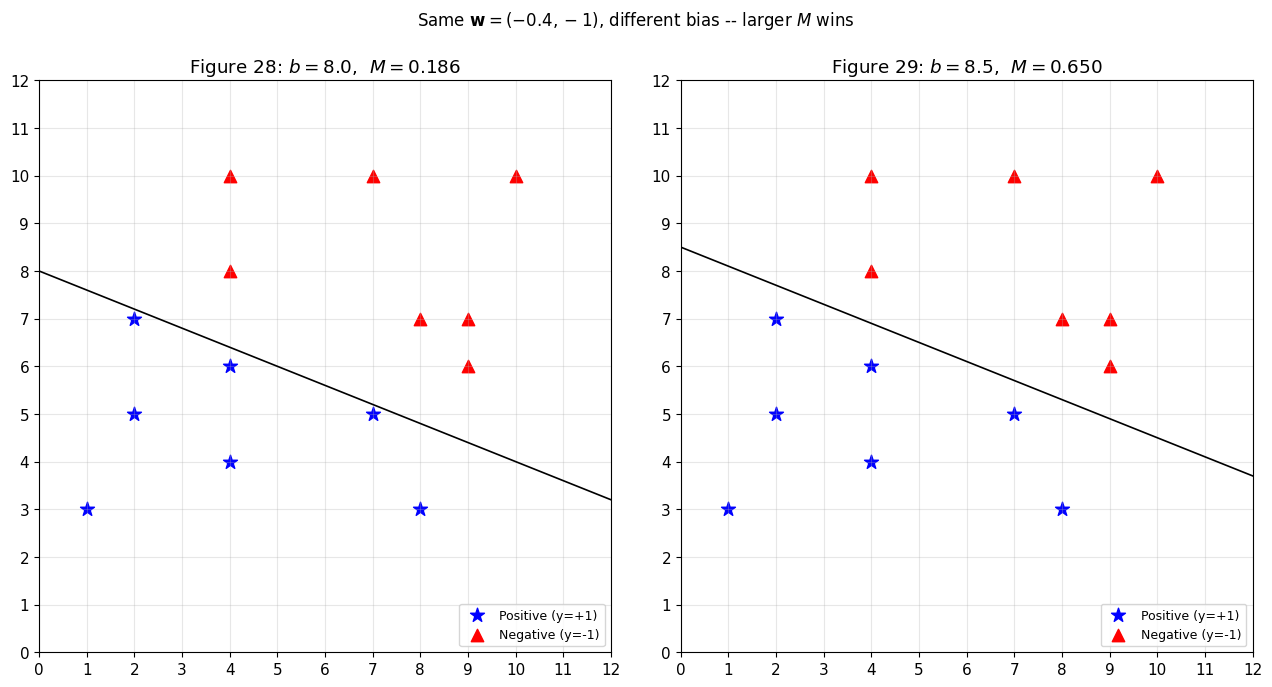

In [9]:
# Visualize Figures 28 and 29 side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

x_grid = np.linspace(0, 12, 100)
pos = np.array(positive_x); neg = np.array(negative_x)

for ax, b_val, M_val, title in [
    (axes[0], 8.0, M_b8,  f'Figure 28: $b = 8.0$,  $M = {M_b8:.3f}$'),
    (axes[1], 8.5, M_b85, f'Figure 29: $b = 8.5$,  $M = {M_b85:.3f}$'),
]:
    # Hyperplane:  -0.4 x1 - x2 + b = 0  =>  x2 = -0.4 x1 + b
    y_grid = -0.4 * x_grid + b_val
    ax.plot(x_grid, y_grid, 'k-', linewidth=1.2)
    ax.scatter(pos[:,0], pos[:,1], marker='*', s=110, c='blue', label='Positive (y=+1)')
    ax.scatter(neg[:,0], neg[:,1], marker='^', s=80,  c='red',  label='Negative (y=-1)')
    ax.set_xlim(0, 12); ax.set_ylim(0, 12)
    ax.set_xticks(range(13)); ax.set_yticks(range(13))
    ax.set_aspect('equal'); ax.set_title(title)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('Same $\\mathbf{w}=(-0.4,-1)$, different bias -- larger $M$ wins',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

The figure makes the comparison vivid: both lines have the same slope (because $\mathbf{w}$ is the same), but shifting $b$ from $8.0$ to $8.5$ raises the line and pushes it farther from the blue stars without crossing into the red triangles. The geometric margin captures this shift quantitatively.

Now we know how to *score* a hyperplane. The remaining task is to find the hyperplane that maximizes the score. This is an **optimization problem**, and the next section reviews the language we will use to write it down.

## 3. What is an optimization problem?

An **optimization problem** asks for the value of a variable $x$ that minimizes (or maximizes) an *objective function* $f(x)$, possibly subject to *constraints*. The variable $x$ can be a scalar, a vector, or even a matrix. The notation we use is

$$\min_{x} \; f(x) \qquad\text{or}\qquad \max_{x}\; f(x).$$

When there are no constraints, the problem is **unconstrained** and the optimizer is free to consider any value of $x$.

### 3.1 Unconstrained problems

The simplest example is

$$\min_{x} \; x^2.$$

The minimum is $0$, attained at $x = 0$. Figure 30 in the chapter shows the parabola.

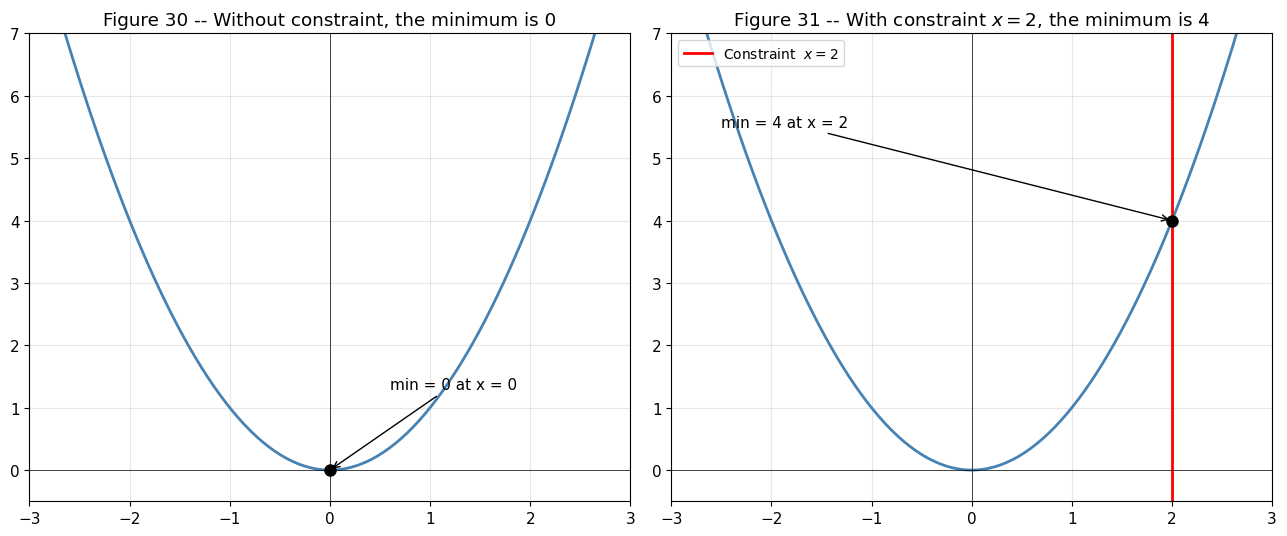

In [10]:
# Visualize Figures 30 and 31: x^2 unconstrained, and constrained by x = 2
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

x_grid = np.linspace(-3, 3, 200)
y_grid = x_grid**2

# Figure 30 -- unconstrained
ax = axes[0]
ax.plot(x_grid, y_grid, color='steelblue', linewidth=2)
ax.plot(0, 0, 'o', color='black', markersize=8)
ax.annotate('min = 0 at x = 0', (0, 0), xytext=(0.6, 1.3),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)
ax.set_xlim(-3, 3); ax.set_ylim(-0.5, 7)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Figure 30 -- Without constraint, the minimum is 0')

# Figure 31 -- constrained by x = 2
ax = axes[1]
ax.plot(x_grid, y_grid, color='steelblue', linewidth=2)
ax.axvline(2, color='red', linewidth=2, label='Constraint  $x = 2$')
ax.plot(2, 4, 'o', color='black', markersize=8)
ax.annotate('min = 4 at x = 2', (2, 4), xytext=(-2.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)
ax.set_xlim(-3, 3); ax.set_ylim(-0.5, 7)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.legend(loc='upper left', fontsize=10)
ax.set_title('Figure 31 -- With constraint $x = 2$, the minimum is 4')

plt.tight_layout(); plt.show()

The left panel shows the unconstrained problem $\min_x x^2$: the minimum is $0$ at $x = 0$. The right panel adds the constraint $x = 2$ (the red vertical line). Now the optimizer is no longer free to wander -- it must pick a value where the constraint is satisfied. The only feasible point is $x = 2$, and the minimum value is $f(2) = 4$.

**Quantitative insight.** Adding the constraint *increased* the minimum from $0$ to $4$. This is a general principle in optimization (Gershwin, 2010): **adding a constraint never improves the optimum -- at best it leaves it unchanged, and typically it makes it worse**. Constraints are restrictions on the search space; they cannot help us find a smaller value than we could find without them.

This principle has a direct relevance to SVMs: the margin constraints $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \geq 1$ force the optimizer to leave a corridor around the hyperplane. Removing these constraints would let $\|\mathbf{w}\|^2 \to 0$ trivially, but the resulting "margin" would be useless.

### 3.2 Constrained optimization with a single equality constraint

The standard way to write a constrained problem is

$$\begin{aligned}
\min_{x} \quad & f(x)\\
\text{subject to} \quad & x - 2 = 0.
\end{aligned}$$

Note the rewriting: $x = 2$ becomes $x - 2 = 0$. We always keep $0$ on the right side so the constraint is in the canonical form $g(x) = 0$.

When the objective $f(x) = x^2$ is quadratic and the constraint $g(x) = x - 2$ is *affine* (linear plus constant), the problem is called a **quadratic program** (QP). QPs are important because they have very efficient solvers and -- the punchline of this chapter -- **the SVM training problem is a QP**.

### 3.3 Feasible set

The set of variables that satisfy all constraints is the **feasible set** (or feasible region). The optimizer searches only inside this set. For the constraint $x = 2$, the feasible set is the single point $\{2\}$ -- a trivial example, but illustrative: with multiple variables and constraints the feasible set becomes a curve, surface, or polytope.

### 3.4 Multiple equality constraints, vector notation

For a problem in $n$ variables it is cleaner to switch to vector notation. With $\mathbf{x} = (x_1, x_2, x_3)^T$ and $f(\mathbf{x}) = x_1^2 - x_2 + x_3^2$, three equality constraints can be written

$$\begin{aligned}
\min_{\mathbf{x}} \quad & f(\mathbf{x})\\
\text{subject to} \quad & x_1 - 2 = 0\\
& x_2 + 8 = 0\\
& x_3 + 3 = 0.
\end{aligned}$$

Watch out for **infeasibility**: if you specify $x - 2 = 0$ *and* $x - 8 = 0$ simultaneously, no $x$ satisfies both. The feasible set is empty and the problem has no solution.

### 3.5 Inequality constraints

Constraints can also be inequalities. The problem

$$\begin{aligned}
\min_{x,y} \quad & x^2 + y^2\\
\text{subject to} \quad & x - 2 \geq 0\\
& y \geq 0
\end{aligned}$$

restricts the feasible set to the upper-right region $\{(x, y) : x \geq 2,\; y \geq 0\}$. Equality and inequality constraints can be mixed freely in the same problem -- and the SVM problem we are about to derive uses **only inequality constraints**, one per training example.

## 4. The SVM optimization problem

We have all the pieces. Given a linearly separable training set

$$\mathcal{D} = \{(\mathbf{x}_i, y_i) \,|\, \mathbf{x}_i \in \mathbb{R}^p,\; y_i \in \{-1, +1\}\}_{i=1}^{m},$$

the **optimal separating hyperplane** is the one with the largest geometric margin

$$M = \min_{i=1\dots m} \gamma_i,\qquad \gamma_i = y_i\left(\frac{\mathbf{w}}{\|\mathbf{w}\|}\cdot \mathbf{x}_i + \frac{b}{\|\mathbf{w}\|}\right).$$

The natural way to write the optimization problem is

$$\begin{aligned}
\max_{\mathbf{w},\,b} \quad & M\\
\text{subject to} \quad & \gamma_i \geq M, \quad i = 1,\dots,m.
\end{aligned}$$

Read the constraint as: *every example must be at least $M$ away from the hyperplane*. Maximizing $M$ pushes the closest training point as far as possible from the decision boundary -- this is the **maximum margin principle**, and it is what makes SVMs SVMs.

### 4.1 The five-step transformation to a clean QP

The form above is unwieldy because $M$ appears both as the objective and inside the constraint, and the constraints involve $\|\mathbf{w}\|$ in the denominator. We now perform five rewriting steps that turn it into the clean convex QP every SVM paper uses.

**Step 1 -- substitute the geometric/functional margin relationship.** Recall $M = F/\|\mathbf{w}\|$, where $F = \min_i f_i = \min_i y_i(\mathbf{w}\cdot\mathbf{x}_i + b)$ is the functional margin. The constraint $\gamma_i \geq M$ becomes $f_i / \|\mathbf{w}\| \geq F/\|\mathbf{w}\|$:

$$\begin{aligned}
\max_{\mathbf{w},\,b} \quad & M\\
\text{subject to} \quad & \frac{f_i}{\|\mathbf{w}\|} \geq \frac{F}{\|\mathbf{w}\|}, \quad i = 1,\dots,m.
\end{aligned}$$

**Step 2 -- cancel $\|\mathbf{w}\|$ on both sides** of the inequality (since $\|\mathbf{w}\| > 0$, the inequality is preserved):

$$\begin{aligned}
\max_{\mathbf{w},\,b} \quad & M\\
\text{subject to} \quad & f_i \geq F, \quad i = 1,\dots,m.
\end{aligned}$$

**Step 3 -- rescale so that $F = 1$.** Because $\gamma$ is scale invariant, rescaling $(\mathbf{w}, b)$ does not change $M$. We are free to choose the scale, so we pick the one that makes the functional margin equal to $1$. The constraints become

$$\begin{aligned}
\max_{\mathbf{w},\,b} \quad & M\\
\text{subject to} \quad & f_i \geq 1, \quad i = 1,\dots,m.
\end{aligned}$$

**Step 4 -- replace $M$ by $1/\|\mathbf{w}\|$.** Since $M = F/\|\mathbf{w}\|$ and we just set $F = 1$:

$$\begin{aligned}
\max_{\mathbf{w},\,b} \quad & \frac{1}{\|\mathbf{w}\|}\\
\text{subject to} \quad & f_i \geq 1, \quad i = 1,\dots,m.
\end{aligned}$$

**Step 5 -- convert maximization to minimization.** Maximizing $1/\|\mathbf{w}\|$ is the same as minimizing $\|\mathbf{w}\|$, which (because the square root is monotonic over non-negative numbers) is the same as minimizing $\|\mathbf{w}\|^2$. Adding the convenience factor $\tfrac{1}{2}$ -- which does not change the minimizer but makes the gradient $\mathbf{w}$ instead of $2\mathbf{w}$ -- gives the canonical form:

$$\boxed{\begin{aligned}
\min_{\mathbf{w},\,b} \quad & \tfrac{1}{2}\|\mathbf{w}\|^2\\
\text{subject to} \quad & y_i(\mathbf{w}\cdot\mathbf{x}_i + b) - 1 \geq 0, \quad i = 1,\dots,m.
\end{aligned}}$$

This is **the SVM optimization problem**. It is what every SVM library, from `libsvm` to `sklearn.svm.SVC`, ultimately solves (or a smooth-margin variant of it).

### 4.2 Why is this a *convex* QP, and why does it matter?

Two properties of the boxed problem above are worth pausing on, because they are the reason SVMs were such a leap over earlier neural classifiers in the 1990s.

**Convexity.** The objective $\tfrac{1}{2}\|\mathbf{w}\|^2 = \tfrac{1}{2}\sum_j w_j^2$ is a convex quadratic. Each constraint $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) - 1 \geq 0$ is *affine* in $(\mathbf{w}, b)$, so the feasible set is the intersection of half-spaces -- a convex polytope. A convex objective minimized over a convex set has **no local minima other than the global minimum**. Whatever the optimizer converges to is the optimum. Compare this with neural network training, where we settle for whatever local minimum SGD happens to find.

**Quadratic structure.** The objective is *quadratic* and the constraints are *linear* -- this is exactly the definition of a **quadratic program**. There are dedicated, mature solvers (interior-point methods, active-set methods, sequential minimal optimization) that find the global optimum to high precision in polynomial time. We will see one such solver applied in the next chapter.

**Strategic / production insight.** The convex QP property has practical consequences a data scientist actually feels. SVM training is **deterministic** -- run it twice with the same data, get the same model. There is no random initialization, no need for restarts, no "lucky seed". For high-stakes deployments where reproducibility matters (medical devices, finance, regulated industries), this property alone can justify choosing a linear SVM over a small neural network of comparable accuracy.

### 4.3 Visualizing what we just derived

Let's visualize the maximum-margin idea on the same toy dataset we used before. We will pick a $(\mathbf{w}, b)$ that is approximately optimal, then rescale it so that the functional margin $F = 1$ (Step 3 of the derivation). After this rescaling, the two parallel lines $\mathbf{w}\cdot\mathbf{x} + b = \pm 1$ are exactly the **margin boundaries**, and the corridor between them has width $2/\|\mathbf{w}\|$ -- precisely twice the geometric margin. Maximizing $1/\|\mathbf{w}\|$ widens this corridor.

Before rescaling:  w = [-0.4 -1. ], b = 8.5
  ||w|| = 1.0770,  M = 0.6499,  F = 0.7000

After rescaling so F = 1:
  w_n = [-0.57142857 -1.42857143]
  ||w_n|| = 1.5386
  b_n = 12.1429
  Margin corridor width = 2/||w_n|| = 1.2999


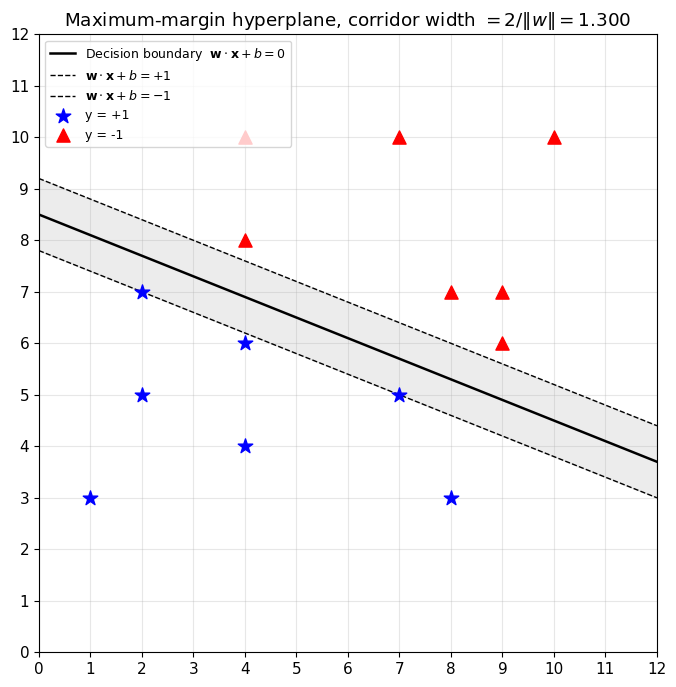

In [11]:
# Visualize the optimal hyperplane and its margin corridor
positive_x_arr = np.array([[2,7],[8,3],[7,5],[4,4],[4,6],[1,3],[2,5]])
negative_x_arr = np.array([[8,7],[4,10],[9,7],[7,10],[9,6],[4,8],[10,10]])

# Hand-tuned w, b that give a wide margin
w  = np.array([-0.4, -1.0])
b  = 8.5
M  = geometric_margin(w, b, np.vstack((positive_x_arr, negative_x_arr)),
                      np.hstack((np.ones(7), -np.ones(7))))

# Step 3 of derivation: rescale so the functional margin F = 1
F   = M * np.linalg.norm(w)   # F before rescaling
w_n = w / F
b_n = b / F

print(f"Before rescaling:  w = {w}, b = {b}")
print(f"  ||w|| = {np.linalg.norm(w):.4f},  M = {M:.4f},  F = {F:.4f}")
print(f"\nAfter rescaling so F = 1:")
print(f"  w_n = {w_n}")
print(f"  ||w_n|| = {np.linalg.norm(w_n):.4f}")
print(f"  b_n = {b_n:.4f}")
print(f"  Margin corridor width = 2/||w_n|| = {2/np.linalg.norm(w_n):.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
x_grid = np.linspace(0, 12, 200)

y_db  = (-w_n[0]*x_grid - b_n)     / w_n[1]   # decision boundary
y_pos = (-w_n[0]*x_grid - b_n + 1) / w_n[1]   # +1 margin
y_neg = (-w_n[0]*x_grid - b_n - 1) / w_n[1]   # -1 margin

ax.plot(x_grid, y_db,  'k-',  linewidth=1.8, label='Decision boundary  $\\mathbf{w}\\cdot\\mathbf{x}+b=0$')
ax.plot(x_grid, y_pos, 'k--', linewidth=1.0, label='$\\mathbf{w}\\cdot\\mathbf{x}+b=+1$')
ax.plot(x_grid, y_neg, 'k--', linewidth=1.0, label='$\\mathbf{w}\\cdot\\mathbf{x}+b=-1$')
ax.fill_between(x_grid, y_neg, y_pos, color='gray', alpha=0.15)

ax.scatter(positive_x_arr[:,0], positive_x_arr[:,1],
           marker='*', s=120, c='blue', label='y = +1', zorder=3)
ax.scatter(negative_x_arr[:,0], negative_x_arr[:,1],
           marker='^', s=90,  c='red',  label='y = -1', zorder=3)

ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.set_xticks(range(13)); ax.set_yticks(range(13))
ax.set_aspect('equal')
ax.set_title(f'Maximum-margin hyperplane, corridor width $= 2/\\|w\\| = {2/np.linalg.norm(w_n):.3f}$')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

The figure shows the three lines that the SVM produces:

- the **solid line** is the decision boundary $\mathbf{w}\cdot\mathbf{x} + b = 0$;
- the **two dashed lines** are the *margin boundaries* $\mathbf{w}\cdot\mathbf{x} + b = +1$ (close to the positive class) and $\mathbf{w}\cdot\mathbf{x} + b = -1$ (close to the negative class);
- the **shaded corridor** is the margin -- a no-mans-land of width $2/\|\mathbf{w}_n\| \approx 1.300$ in our scaling.

Three observations follow from the constraint $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \geq 1$:

1. **No training point lies strictly inside the corridor** -- the constraint forbids it.
2. The points that lie *exactly on* the dashed lines are the **support vectors**. They are the only points for which the constraint is *active* (holds with equality, $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) = 1$). Removing any non-support-vector training point leaves the optimal hyperplane unchanged.
3. **Maximizing $1/\|\mathbf{w}\|$ widens the corridor.** That is what the SVM objective is doing: pushing the dashed lines as far apart as possible while keeping every point on the correct side.

**Cross-chapter preview.** The next chapter solves this QP using Lagrangian duality, which will reveal that the optimal $\mathbf{w}$ can be expressed as a sparse linear combination of *only the support vectors*:
$$\mathbf{w}^\star = \sum_{i\in \text{SV}} \alpha_i^\star\, y_i\, \mathbf{x}_i.$$
This is where the kernel trick eventually slots in: because the dual depends on the data only through dot products $\mathbf{x}_i \cdot \mathbf{x}_j$, we can replace those with $K(\mathbf{x}_i, \mathbf{x}_j)$ for any kernel $K$, and we get nonlinear SVMs essentially for free.

## 5. Summary

The chapter walked us through the construction of the SVM optimization problem in five conceptual stages:

1. **Some hyperplanes are better than others** -- they generalize better to unseen data. Among the infinite family of separating hyperplanes for a linearly separable dataset, we want *the* one we will call **optimal**.

2. **Comparing hyperplanes requires a number.** A first attempt $B = \min_i (\mathbf{w}\cdot\mathbf{x}_i + b)$ failed for examples on the negative side and ignored classification correctness.

3. **The functional margin** $F = \min_i y_i(\mathbf{w}\cdot\mathbf{x}_i + b)$ fixed correctness but failed scale invariance: rescaling $(\mathbf{w}, b)$ by $10$ multiplied $F$ by $10$ without changing the hyperplane (we saw $F$ go from $8$ to $80$).

4. **The geometric margin** $M = \min_i \gamma_i = \min_i y_i\!\left(\frac{\mathbf{w}}{\|\mathbf{w}\|}\cdot\mathbf{x}_i + \frac{b}{\|\mathbf{w}\|}\right)$ fixed both problems. It is a real perpendicular distance, signed by the label, and invariant under rescaling. It is the right objective.

5. **Maximizing $M$ is equivalent to a clean convex QP.** Through the rescaling trick $F = 1$ we transformed
$$\max_{\mathbf{w},\,b}\, M \;\;\text{s.t.}\;\; \gamma_i \geq M \quad\Longrightarrow\quad \min_{\mathbf{w},\,b}\, \tfrac{1}{2}\|\mathbf{w}\|^2 \;\;\text{s.t.}\;\; y_i(\mathbf{w}\cdot\mathbf{x}_i + b) - 1 \geq 0.$$

The final form has two properties that make SVMs uniquely tractable: the objective is **convex** (no local minima besides the global one), and the constraints are **affine** (the feasible set is a convex polytope). This is the canonical convex QP, and it is what we will solve next chapter.

### What we have *not* yet handled

- **Non-separable data.** If no hyperplane separates the classes, every constraint $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \geq 1$ cannot be satisfied simultaneously and the feasible set is empty. The fix is **slack variables** $\xi_i \geq 0$, leading to the soft-margin SVM. This will be addressed in a later chapter.
- **Nonlinear boundaries.** The current formulation gives only *linear* decision boundaries. The kernel trick, also covered later, lifts this restriction without changing the QP structure.
- **Solving the QP.** We have the problem; we have not yet shown how to solve it. The next chapter introduces Lagrangian duality and the KKT conditions to do so.

The SVM derivation in this chapter is one of the most elegant pieces of mathematical engineering in machine learning: a learning algorithm whose entire training procedure is the solution of a *single, deterministic, globally optimal* convex program -- something neural networks still do not enjoy three decades later.